In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

First Five Records
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None

Statistical Summary
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


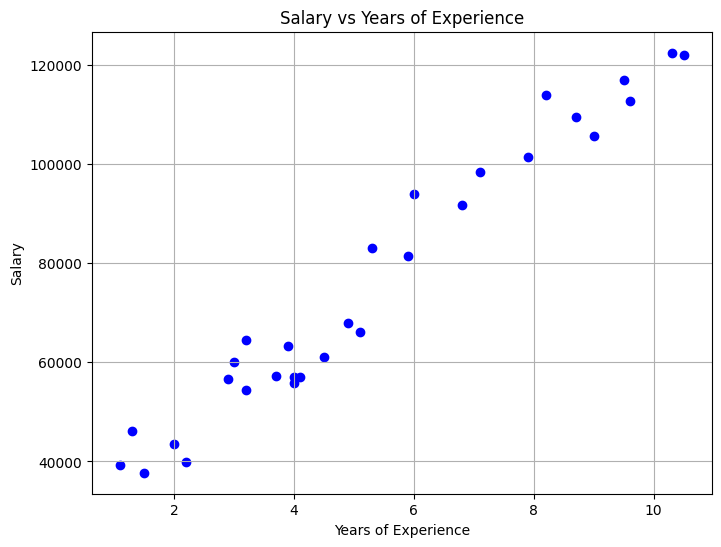

In [ ]:
# Load Dataset
data = pd.read_csv("Salary_Data.csv")

print("First Five Records")
print(data.head())
print("\nDataset Information")
print(data.info())
print("\nStatistical Summary")
print(data.describe())

# Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(data["YearsExperience"], data["Salary"], color="blue")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Years of Experience")
plt.grid(True)
plt.show()

In [ ]:
# Prepare Data
X = data[["YearsExperience"]]
y = data["Salary"]
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [ ]:
# LINEAR REGRESSION

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# Evaluation Metrics

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("\n========== Linear Regression ==========")

print("Intercept :", linear_model.intercept_)
print("Coefficient :", linear_model.coef_[0])
print("\nMAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R2 Score:", r2_linear)


========== Linear Regression ==========
Intercept : 25918.438334893202
Coefficient : 9339.081723815198

MAE : 5161.328710400183
MSE : 37784662.46621314
RMSE: 6146.92300799458
R2 Score: 0.9414466227178214


In [ ]:
# POLYNOMIAL REGRESSION
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluation Metrics

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("\n========== Polynomial Regression ==========")

print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)
print("R2 Score:", r2_poly)


========== Polynomial Regression ==========
MAE : 5199.78207394021
MSE : 38366233.44282789
RMSE: 6194.0482273572825
R2 Score: 0.9405453854806081


In [ ]:
# Comparison Table
comparison = pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R2 Score"],
    "Linear Regression":[
        mae_linear,
        mse_linear,
        rmse_linear,
        r2_linear
    ],
    "Polynomial Regression":[
        mae_poly,
        mse_poly,
        rmse_poly,
        r2_poly
    ]
})
print("\nComparison of Models")
print(comparison)


Comparison of Models
     Metric  Linear Regression  Polynomial Regression
0       MAE       5.161329e+03           5.199782e+03
1       MSE       3.778466e+07           3.836623e+07
2      RMSE       6.146923e+03           6.194048e+03
3  R2 Score       9.414466e-01           9.405454e-01


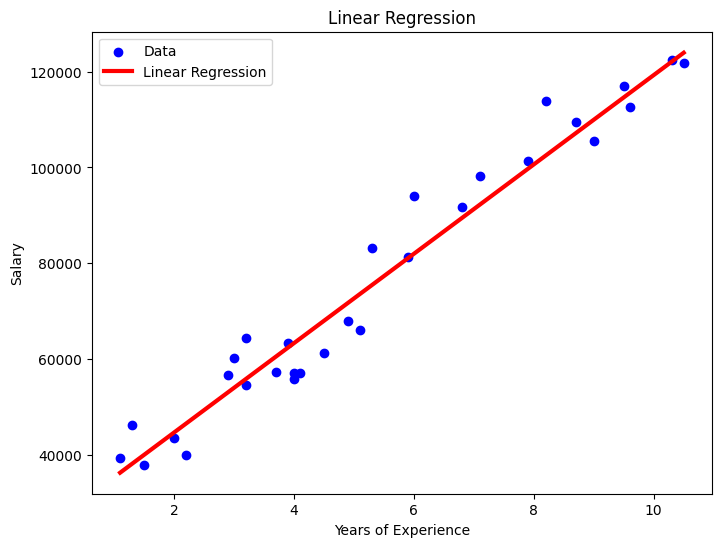

In [ ]:
# Linear Regression Curve

plt.figure(figsize=(8,6))
plt.scatter(X, y, color="blue", label="Data")
plt.plot(
    X,
    linear_model.predict(X),
    color="red",
    linewidth=3,
    label="Linear Regression"
)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")
plt.legend()
plt.grid(False)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


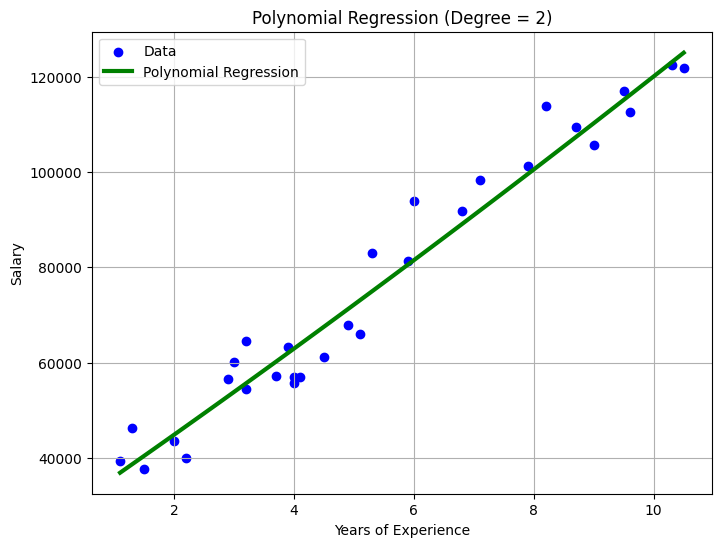

In [ ]:
# Polynomial Regression Curve
X_grid = np.linspace(
    X.min(),
    X.max(),
    100
).reshape(-1,1)
X_grid_poly = poly.transform(X_grid)
plt.figure(figsize=(8,6))
plt.scatter(X, y, color="blue", label="Data")
plt.plot(
    X_grid,
    poly_model.predict(X_grid_poly),
    color="green",
    linewidth=3,
    label="Polynomial Regression"
)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Polynomial Regression (Degree = 2)")
plt.legend()
plt.grid(True)
plt.show()

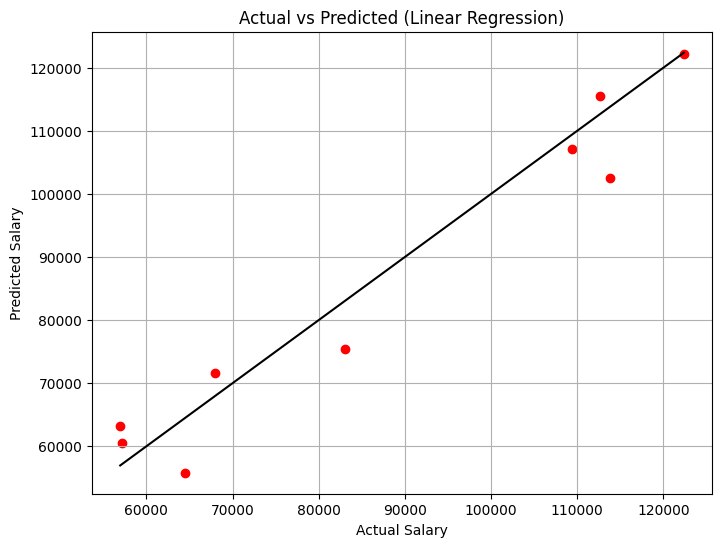

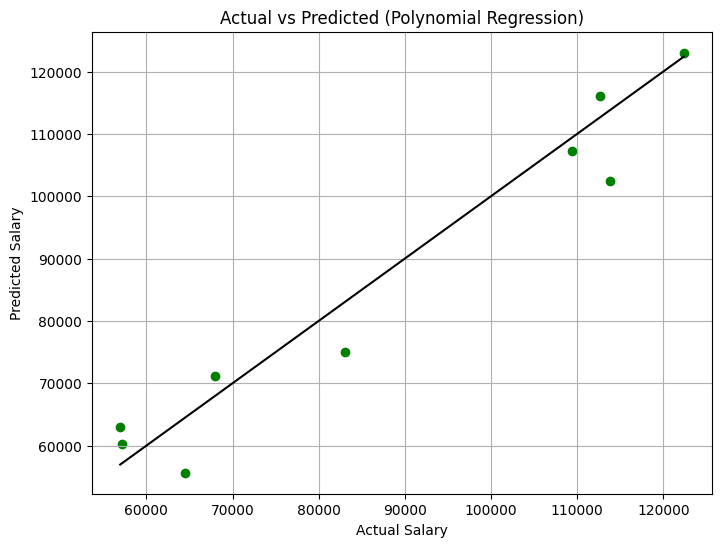

In [ ]:
# Actual vs Predicted (Linear)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_linear, color="red")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="black"
)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted (Linear Regression)")
plt.grid(True)
plt.show()

# Actual vs Predicted (Polynomial)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_poly, color="green")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="black"
)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted (Polynomial Regression)")
plt.grid(True)
plt.show()